# Geometry (mapped domains)

In Struphy, a computational domain is defined by a **mapping** from logical coordinates to physical space. Concretely, we use a map
$$
F:(0,1)^3 \rightarrow \Omega,\qquad \boldsymbol{\eta}=(\eta_1,\eta_2,\eta_3) \mapsto \mathbf{x}=(x,y,z),
$$
where the logical unit cube is easy to mesh, and the mapping bends this mesh into the physical geometry of interest.

This is why mapped domains are so useful: we can keep structured discretizations in logical space while representing curved geometries (cylinders, tori, tokamaks, stellarators) in physical space.

A practical challenge is the **polar singularity** (the magnetic axis). In Struphy, two strategies are common:

1. Use `polar splines` in the de Rham setup (more expensive).
2. Cut out a small hole around the axis (cheap, but particles cannot live in that excluded region).

In this tutorial we focus on the second strategy and build intuition from simple to more physics-driven mappings.

## HollowCylinder

We start with `HollowCylinder`, the simplest curvilinear example: a cylindrical shell obtained from the logical cube by an analytical mapping.

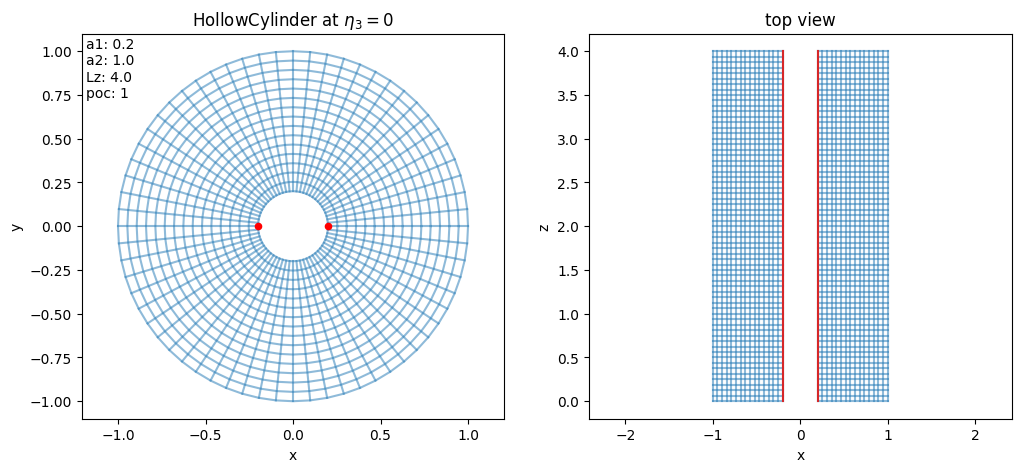

In [1]:
from struphy import domains

domain = domains.HollowCylinder()
domain.show()

A 3D rendering helps to connect the mapping parameters to geometry: inner radius, outer radius, and length become visually obvious.

In [2]:
domain.show_3d()

2026-07-23 08:28:20.610 (   1.507s) [    7FBBD0678B80]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=
2026-07-23 08:28:20.610 (   1.507s) [    7FBBD0678B80]vtkOpenGLRenderWindow.c:645   WARN| Failed to load EGL! Please install the EGL library from your distribution's package manager.
2026-07-23 08:28:22.776 (   3.673s) [    7FBBD0678B80]vtkOpenGLRenderWindow.c:645   WARN| Failed to load EGL! Please install the EGL library from your distribution's package manager.


Widget(value='<iframe src="http://localhost:41769/index.html?ui=P_0x7fbbc8157f40_0&reconnect=auto" class="pyvi…

Let us inspect the default parameters of `HollowCylinder`. Read them as: `a1` = inner radius, `a2` = outer radius, `Lz` = axial length, and `poc` controls angular periodicity ("piece of cake").

In [3]:
for key, val in domain.params.items():
    print(key, "=", val)

a1 = 0.2
a2 = 1.0
Lz = 4.0
poc = 1


`poc` lets us model only a sector of the full cylinder and reconstruct periodicity through the mapping. This is useful when symmetry allows reducing the simulated angular extent.

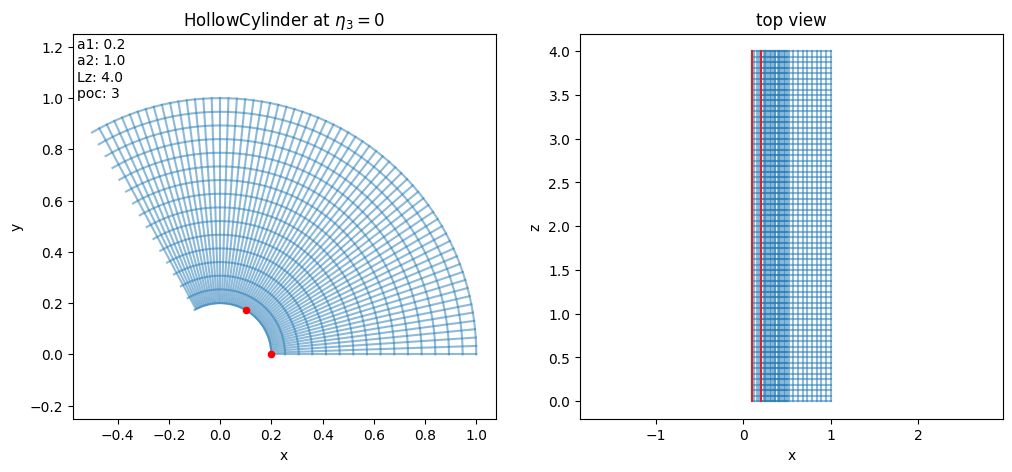

In [4]:
domain_poc = domains.HollowCylinder(poc=3)
domain_poc.show()

Some key attributes to interpret are:

- `kind_map`: internal mapping family identifier (`20-29` are cylinder/torus analytical mappings).
- `pole`: `True` when the mapping includes a polar singularity on axis.
- `periodic_eta3`: tells whether the logical direction $\eta_3$ is periodic in this mapping.

In [5]:
print(domain.kind_map)
print(domain.pole)
print(domain.periodic_eta3)

20
False
False


It is also useful to inspect callable methods of a domain object: this shows what geometric operations (mapping, Jacobian, metric-related helpers, visualization, etc.) are available for downstream workflows.

In [6]:
for attr in dir(domain):
    if callable(getattr(domain, attr)) and "__" not in attr and attr[0] != "_":
        print(attr)

create_geometry_mesh
export_geometry
from_dict
get_params_numpy
jacobian
jacobian_det
jacobian_inv
metric
metric_inv
prepare_arg
prepare_eval_pts
pull
push
show
show_3d
to_dict
transform


The domain object is itself callable: evaluating `domain(...)` applies the mapping $F(\eta_1,\eta_2,\eta_3)=(x,y,z)$ from logical to physical coordinates.

In [7]:
help(domain.__call__)

Help on method __call__ in module struphy.geometry.base:

__call__(*etas, change_out_order=False, squeeze_out=False, remove_outside=True, identity_map=False) method of struphy.geometry.domains.HollowCylinder instance
    Evaluates the mapping :math:`F : (0, 1)^3 \to \mathbb R^3,\, \boldsymbol \eta \mapsto \mathbf x`.
    
    Logical coordinates outside of :math:`(0, 1)^3` are evaluated to -1.
    The type of evaluation depends on the shape of the input ``etas``.
    
    Parameters
    ----------
    *etas : array-like | tuple
        Logical coordinates at which to evaluate. Two cases are possible:
            1. 2d numpy array, where coordinates are taken from eta1 = etas[:, 0], eta2 = etas[:, 1], etc. (like markers).
            2. list/tuple (eta1, eta2, ...), where eta1, eta2, ... can be float or array-like of various shapes.
    
    change_out_order : bool
        If True, the axis corresponding to x, y, z coordinates in the output array is the last one, otherwise the first one

Now we vary `a1` to control how much of the axis neighborhood is removed. Increasing `a1` enlarges the excluded core and avoids singular behavior at the center.

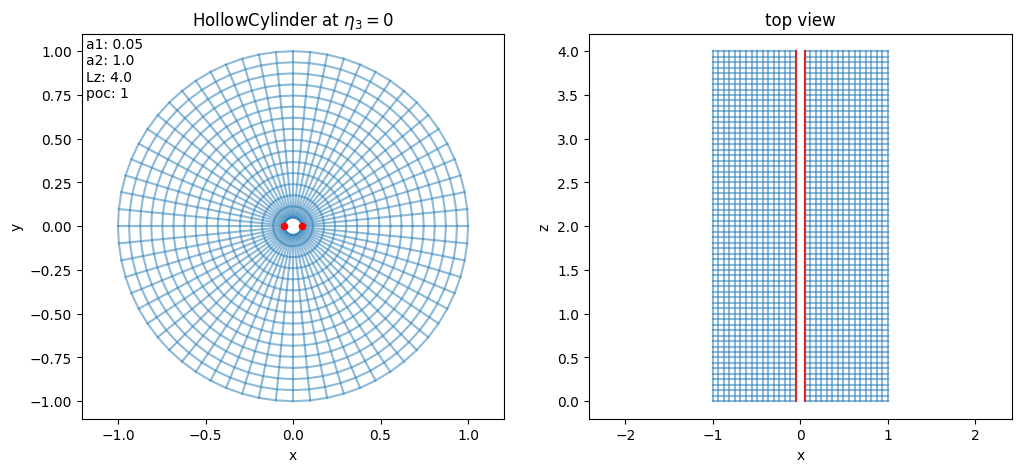

In [8]:
domain = domains.HollowCylinder(a1=0.05)
domain.show()

If we set `a1=0`, the hole disappears and the axis is included. In that case, `domain.pole` becomes `True`, signaling the polar singularity discussed in the introduction.

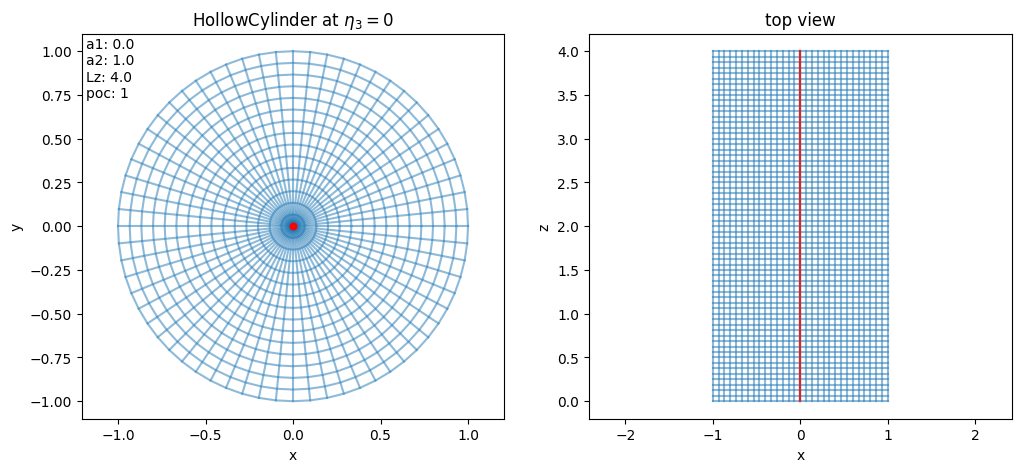

In [9]:
domain = domains.HollowCylinder(a1=0.0)
domain.show()

In [10]:
print(domain.kind_map)
print(domain.pole)
print(domain.periodic_eta3)

20
True
False


## HollowTorus

`HollowTorus` extends the same idea to toroidal geometry: the logical cube is mapped to a torus with optional inner hole around the magnetic axis.

Compared to `HollowCylinder`, important new parameters are:
- `R0`: major radius (distance from torus center to tube center),
- `sfl`: whether to use straight-field-line poloidal parametrization,
- `tor_period`: built-in toroidal periodicity (e.g. `3` means one third of a full torus in the mapped geometry).

Let us create [HollowTorus](https://struphy.pages.mpcdf.de/struphy/sections/domains.html#struphy.geometry.domains.HollowTorus) with default parameters:

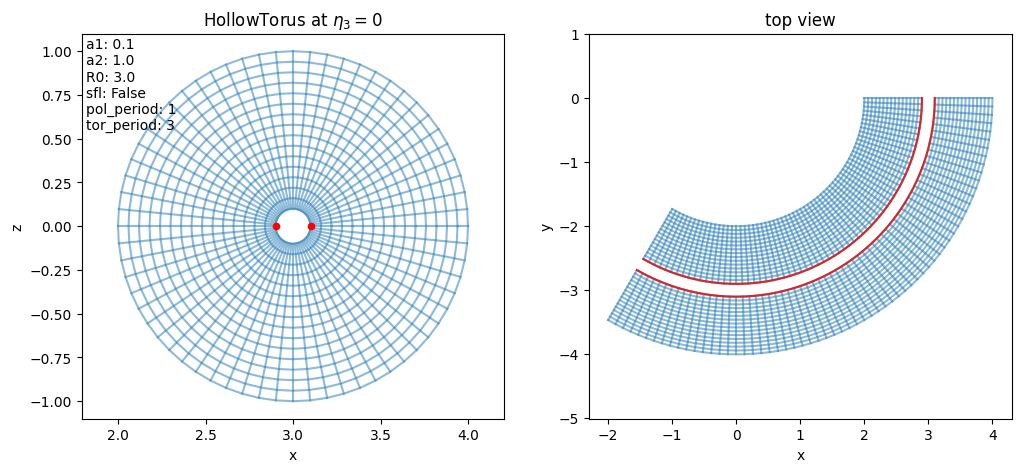

In [11]:
domain = domains.HollowTorus()
domain.show()

For this mapping, `periodic_eta3` is `True` because the toroidal angle is encoded in $\eta_3$ and treated periodically by construction.

In [12]:
print(domain.kind_map)
print(domain.pole)
print(domain.periodic_eta3)

22
False
True


Let us inspect the defaults. In particular, compare `a1/a2` (minor radii), `R0` (major radius), and periodicity-related parameters to understand the torus shape and angular parametrization choices.

In [13]:
for key, val in domain.params.items():
    print(key, "=", val)

a1 = 0.1
a2 = 1.0
R0 = 3.0
sfl = False
pol_period = 1
tor_period = 3


Now we modify three knobs at once:

- `a1` to change the hole around the axis,
- `sfl=True` to switch poloidal coordinates to straight-field-line style,
- `tor_period=1` to represent the full torus period in the map.

This helps build intuition for how coordinate choices alter the geometry and periodicity.

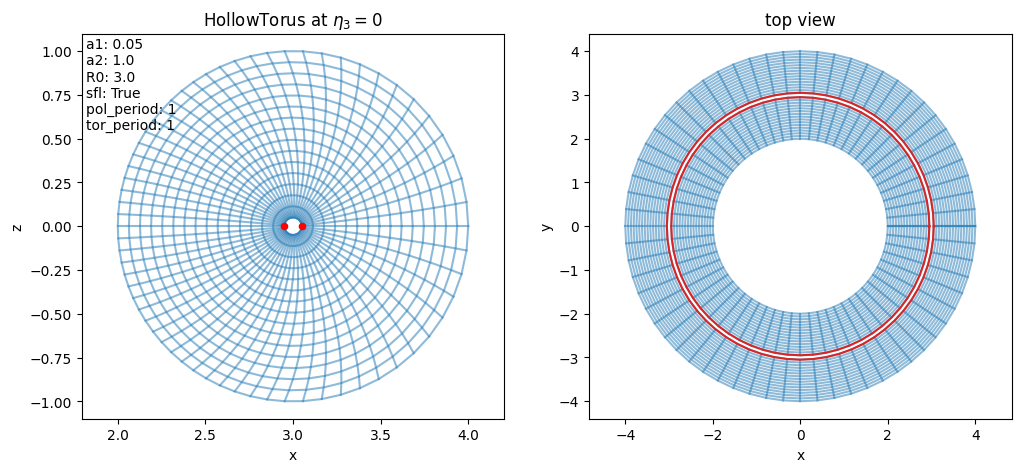

In [14]:
domain = domains.HollowTorus(a1=0.05, sfl=True, tor_period=1)
domain.show()

## Tokamak

For realistic tokamak geometry, Struphy uses mappings tied to an axisymmetric MHD equilibrium. Instead of prescribing a simple analytic torus, the domain is built from a poloidal flux function $\psi$ and field-line tracing.

So conceptually, the workflow is: equilibrium model $\rightarrow$ flux surfaces $\rightarrow$ mapped computational domain.

[Tokamak](https://struphy.pages.mpcdf.de/struphy/sections/domains.html#struphy.geometry.domains.Tokamak) is the domain class implementing this idea.

Let us create a `Tokamak` with default parameters:

/opt/hostedtoolcache/Python/3.10.20/x64/lib/python3.10/site-packages/struphy/fields_background/equils.py:1780: UserWarning: self.units =<struphy.physics.physics.Units object at 0x7fbb1ce3c7c0>, no rescaling performed in EQDSK output.
  warnings.warn(


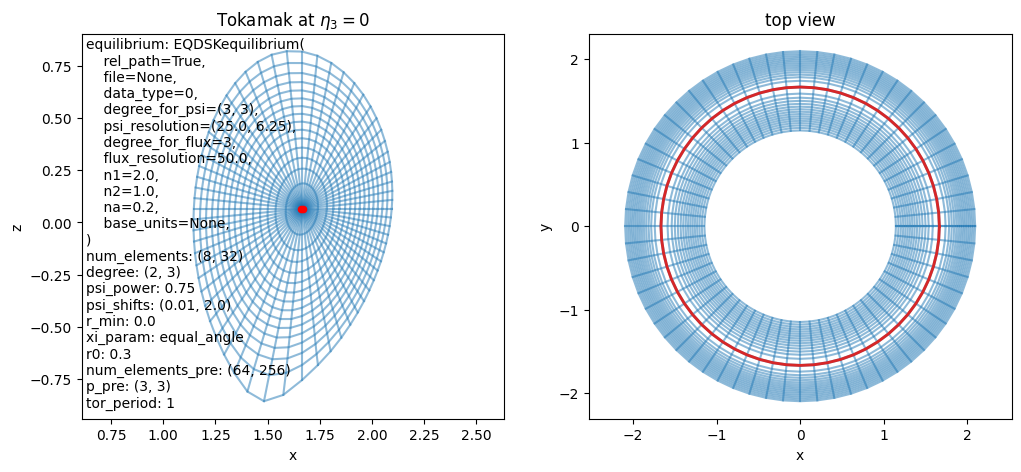

In [15]:
domain = domains.Tokamak()
domain.show()

In [16]:
domain.show_3d()

2026-07-23 08:28:29.716 (  10.613s) [    7FBBD0678B80]vtkOpenGLRenderWindow.c:645   WARN| Failed to load EGL! Please install the EGL library from your distribution's package manager.


Widget(value='<iframe src="http://localhost:41769/index.html?ui=P_0x7fbb3c0462f0_1&reconnect=auto" class="pyvi…

Let us inspect the default tokamak mapping parameters. Notice how they now include options linked to equilibrium/flux-surface construction rather than only simple geometric radii.

In [17]:
for key, val in domain.params.items():
    if "cx" not in key and "cy" not in key:
        print(key, "=", val)

equilibrium = EQDSKequilibrium(
    rel_path=True,
    file=None,
    data_type=0,
    degree_for_psi=(3, 3),
    psi_resolution=(25.0, 6.25),
    degree_for_flux=3,
    flux_resolution=50.0,
    n1=2.0,
    n2=1.0,
    na=0.2,
    base_units=None,
)
num_elements = (8, 32)
degree = (2, 3)
psi_power = 0.75
psi_shifts = (0.01, 2.0)
r_min = 0.0
xi_param = equal_angle
r0 = 0.3
num_elements_pre = (64, 256)
p_pre = (3, 3)
tor_period = 1


A `Tokamak` domain is always coupled to an [AxisymmMHDequilibrium](https://struphy.pages.mpcdf.de/struphy/sections/mhd_equils.html#struphy.fields_background.mhd_equil.base.AxisymmMHDequilibrium), which provides the flux function $\psi$ used to construct the map.

By default, this is [AdhocTorus](https://struphy.pages.mpcdf.de/struphy/sections/mhd_equils.html#struphy.fields_background.mhd_equil.equils.AdhocTorus), a convenient analytic equilibrium for testing. We can also switch to [EQDSKequilibrium](https://struphy.pages.mpcdf.de/struphy/sections/mhd_equils.html#struphy.fields_background.mhd_equil.equils.EQDSKequilibrium), which represents a more realistic equilibrium source.

/opt/hostedtoolcache/Python/3.10.20/x64/lib/python3.10/site-packages/struphy/fields_background/equils.py:1780: UserWarning: self.units =<struphy.physics.physics.Units object at 0x7fbb61040e50>, no rescaling performed in EQDSK output.
  warnings.warn(


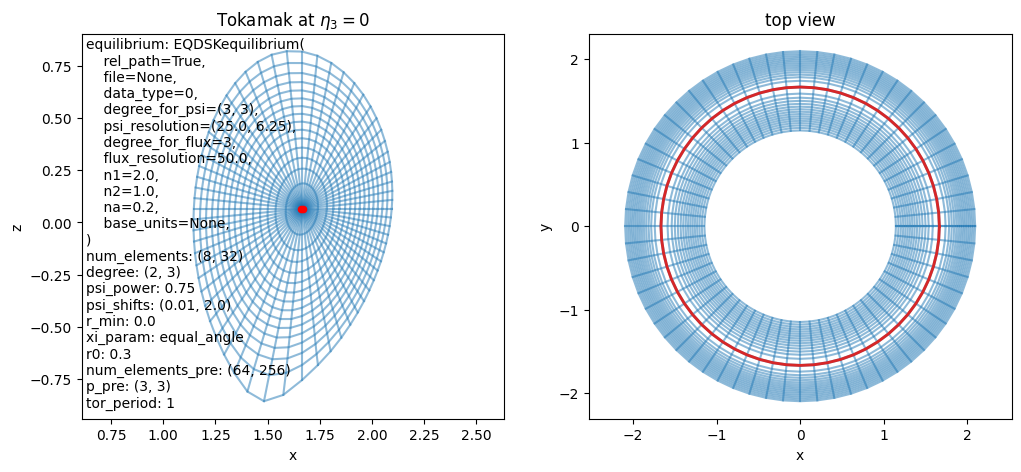

In [18]:
from struphy import equils

mhd_eq = equils.EQDSKequilibrium()

domain = domains.Tokamak(equilibrium=mhd_eq)
domain.show()

Finally, we shrink the inner excluded region by adjusting `psi_shifts`, which changes how close the mapped domain gets to the magnetic axis.

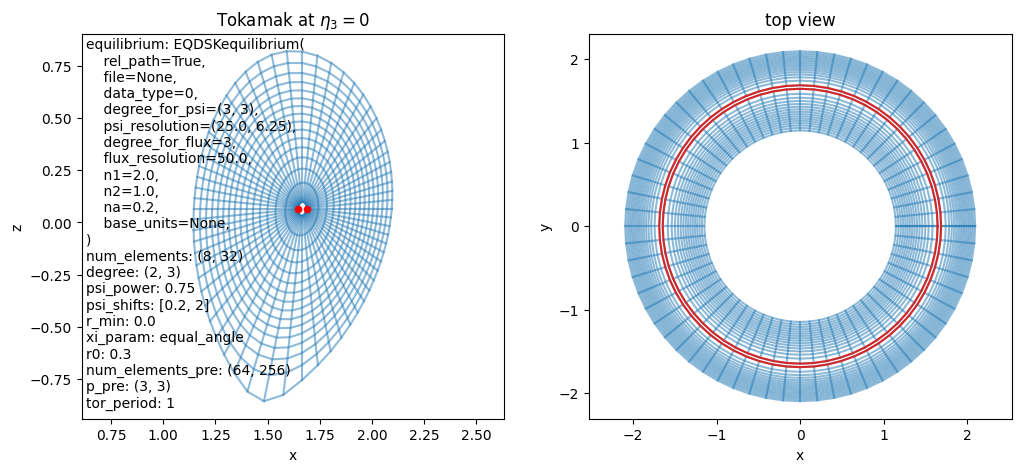

In [19]:
domain = domains.Tokamak(equilibrium=mhd_eq, psi_shifts=[0.2, 2])
domain.show()

## Stellarator mappings

Tokamak mappings above are axisymmetric. Stellarators, in contrast, are intrinsically 3D and typically require equilibrium data generated by dedicated external codes.

Struphy provides interfaces to read equilibrium geometry from:

- [GVEC equilibrium code](https://gitlab.mpcdf.mpg.de/gvec-group/gvec)
- [DESC equilibrium code](https://desc-docs.readthedocs.io/en/latest/index.html)

### GVEC interface

The corresponding Struphy domain class is [GVECunit](https://struphy.pages.mpcdf.de/struphy/sections/domains.html?highlight=gvec#struphy.geometry.domains.GVECunit).
Let us create an instance with default parameters:

/opt/hostedtoolcache/Python/3.10.20/x64/lib/python3.10/site-packages/struphy/fields_background/equils.py:2150: UserWarning: self.units =<struphy.physics.physics.Units object at 0x7fbb5d3b98d0>, no rescaling performed in GVEC output.
  warnings.warn(


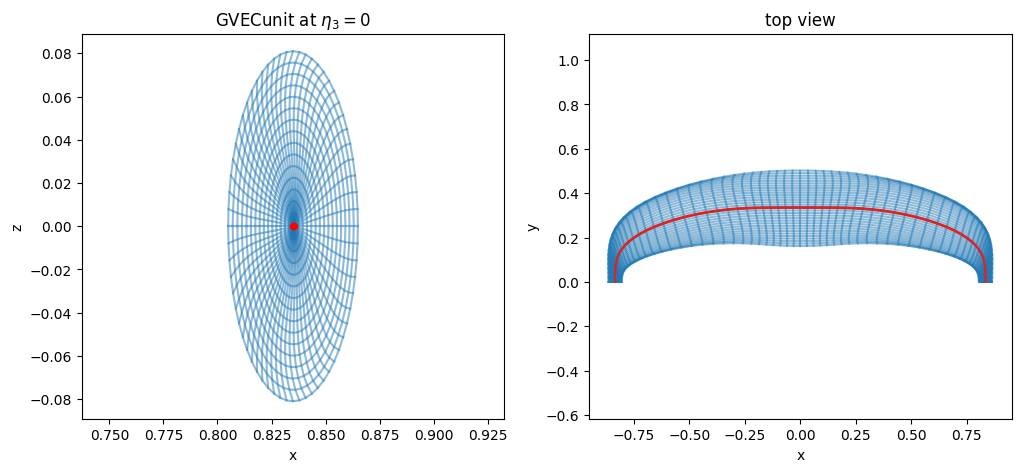

In [20]:
domain = domains.GVECunit()
domain.show()

Inspecting defaults is useful here as well: they describe both geometry controls and how the external equilibrium information is interpreted by the mapping.

In [21]:
for key, val in domain.params.items():
    if "cx" not in key and "cy" not in key and "cz" not in key:
        print(key, "=", val)

Next, we modify equilibrium-side parameters to open a hole around the magnetic axis (`rmin`) and use the whole stellarator (`use_nfp=False`). These settings are passed through [GVECequilibrium](https://struphy.pages.mpcdf.de/struphy/sections/mhd_equils.html#struphy.fields_background.mhd_equil.equils.GVECequilibrium):

/opt/hostedtoolcache/Python/3.10.20/x64/lib/python3.10/site-packages/struphy/fields_background/equils.py:2150: UserWarning: self.units =<struphy.physics.physics.Units object at 0x7fbb03d06a10>, no rescaling performed in GVEC output.
  warnings.warn(


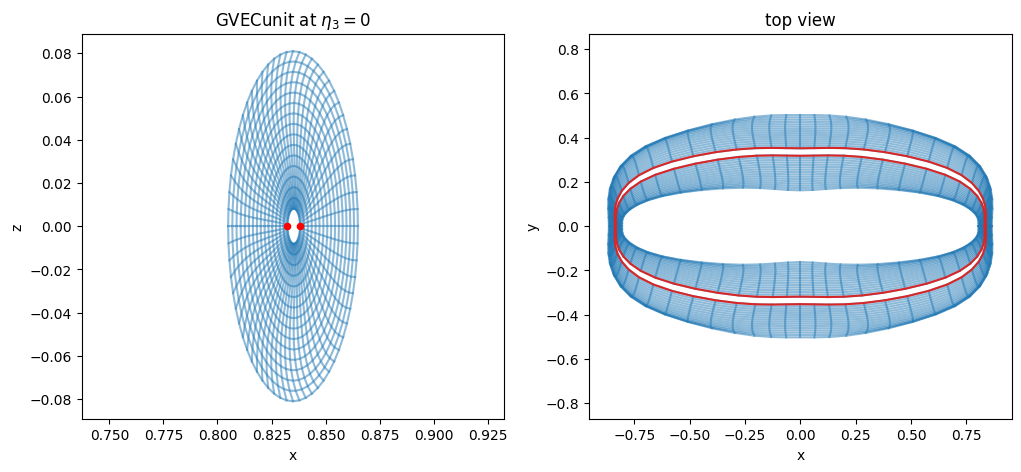

In [22]:
gvec_equil = equils.GVECequilibrium(rmin=0.1, use_nfp=False)
domain = domains.GVECunit(gvec_equil)
domain.show()

### DESC interface

The analogous interface for DESC is [DESCunit](https://struphy.pages.mpcdf.de/struphy/sections/domains.html?highlight=gvec#struphy.geometry.domains.DESCunit).
As with GVEC, equilibrium choices are specified through [DESCequilibrium](https://struphy.pages.mpcdf.de/struphy/sections/mhd_equils.html#struphy.fields_background.mhd_equil.equils.DESCequilibrium), then consumed by the domain mapping:

In [23]:
%%capture
desc_equil = equils.DESCequilibrium(use_nfp=False)
domain = domains.DESCunit(desc_equil)

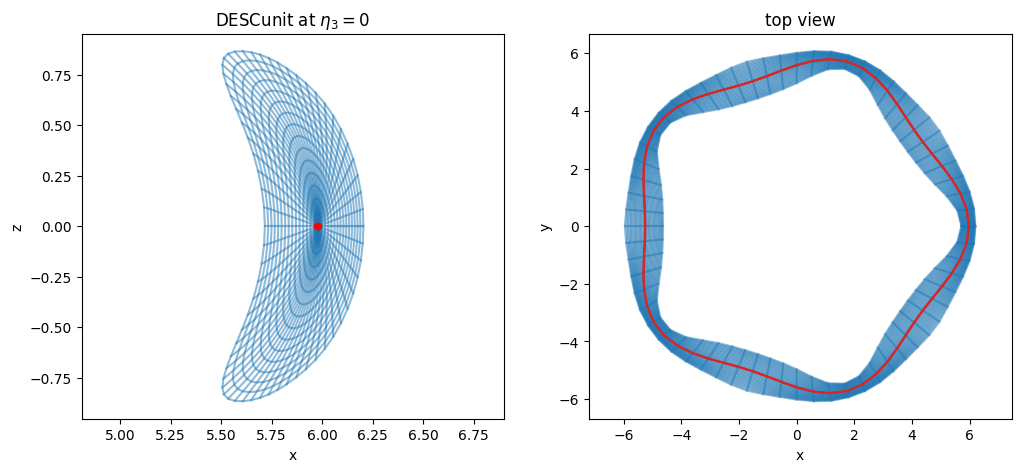

In [24]:
domain.show()